In [1]:
!pip install torch_optimizer numpy torch transformers evaluate python-whois xgboost lightgbm datasets tld --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.9/55.9 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 124.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 94.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [2]:
from datasets import load_dataset
from datasets import Dataset
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing, metrics
import itertools
from sklearn.metrics import classification_report, mean_squared_error,confusion_matrix, f1_score, accuracy_score, precision_score, recall_score, auc,roc_curve
from sklearn.model_selection import train_test_split
import random
import math
from collections import Counter
import xgboost as xgb
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import os
import socket
import whois
from datetime import datetime
import time
from bs4 import BeautifulSoup
import urllib
import bs4
import os
import kagglehub


In [3]:
kagglehub.dataset_download('sid321axn/malicious-urls-dataset')

'/kaggle/input/malicious-urls-dataset'

# Data Understanding

In [4]:
df = pd.read_csv('/kaggle/input/malicious-urls-dataset/malicious_phish.csv')

### Dataset Information

In [5]:
print(df.shape)
print(df.info())

(651191, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 651191 entries, 0 to 651190
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   url     651191 non-null  object
 1   type    651191 non-null  object
dtypes: object(2)
memory usage: 9.9+ MB
None


In [6]:
df.isna().sum()

,0
url,0
type,0


### Data Distribution

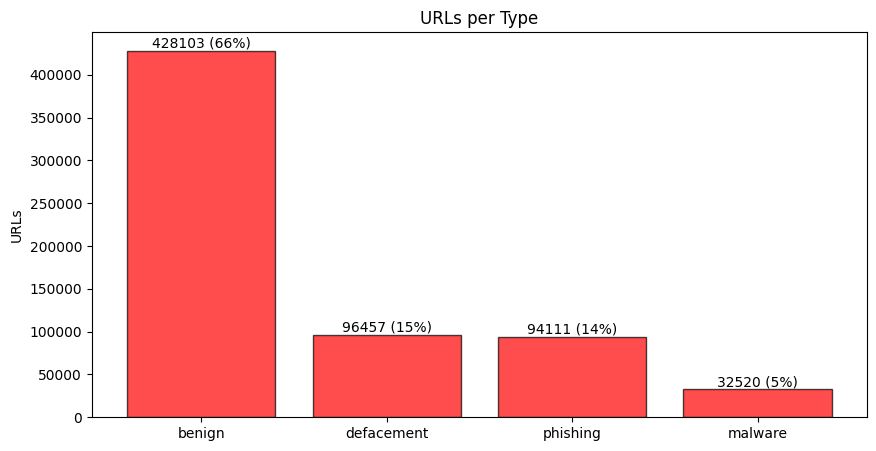

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

types = df['type'].values

counter_types = Counter(types)

type_names = list(counter_types.keys())
type_values = list(counter_types.values())

sorted_indices = np.argsort(type_values)[::-1]
type_names = [type_names[i] for i in sorted_indices]
type_values = [type_values[i] for i in sorted_indices]

percentages = [round(i * 100 / sum(type_values)) for i in type_values]



y_pos = np.arange(len(type_names))
plt.figure(1, figsize=(10, 5))
bars = plt.bar(y_pos, type_values, align='center', alpha=0.7, color='Red', edgecolor='black')

for bar, value,percentage  in zip(bars, type_values, percentages):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{value} ({percentage}%)', ha='center', va='bottom')


plt.xticks(y_pos, type_names)
plt.ylabel('URLs')
plt.title('URLs per Type')
plt.show()

In [8]:
df['url_len'] = [len(url) for url in df.url]
df.head()

,url,type,url_len
0,br-icloud.com.br,phishing,16
1,mp3raid.com/music/krizz_kaliko.html,benign,35
2,bopsecrets.org/rexroth/cr/1.htm,benign,31
3,http://www.garage-pirenne.be/index.php?option=...,defacement,88
4,http://adventure-nicaragua.net/index.php?optio...,defacement,235


## Label Encoding

In [9]:
from sklearn.preprocessing import LabelEncoder

le= LabelEncoder()
le.fit(df["type"])

df["type_code"] = le.transform(df["type"])

In [10]:
le_label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
le_label_mapping

{'benign': np.int64(0),
 'defacement': np.int64(1),
 'malware': np.int64(2),
 'phishing': np.int64(3)}

In [11]:
# Convert DataFrame to HF Dataset
df = df[['url', 'type', 'type_code']]
dataset = Dataset.from_pandas(df, preserve_index=False)
dataset

Dataset({
    features: ['url', 'type', 'type_code'],
    num_rows: 651191
})

In [12]:
# split train to 70% of total and test to 30% of total
train_test_dataset = dataset.train_test_split(test_size=0.3, seed=42, shuffle=True)
train_test_dataset

DatasetDict({
    train: Dataset({
        features: ['url', 'type', 'type_code'],
        num_rows: 455833
    })
    test: Dataset({
        features: ['url', 'type', 'type_code'],
        num_rows: 195358
    })
})

In [13]:
# split the validation test to 20% of total and test set to 10% of total
val_test_dataset = train_test_dataset['test'].train_test_split(test_size=0.33, seed=42, shuffle=True)
val_test_dataset

DatasetDict({
    train: Dataset({
        features: ['url', 'type', 'type_code'],
        num_rows: 130889
    })
    test: Dataset({
        features: ['url', 'type', 'type_code'],
        num_rows: 64469
    })
})

In [14]:
from datasets import DatasetDict

# 70% train, 20% validation, 10% test
dataset = DatasetDict({
    'train': train_test_dataset['train'],
    'val': val_test_dataset['train'],
    'test': val_test_dataset['test'],
})
dataset = dataset.rename_column("type_code", "labels")
dataset

DatasetDict({
    train: Dataset({
        features: ['url', 'type', 'labels'],
        num_rows: 455833
    })
    val: Dataset({
        features: ['url', 'type', 'labels'],
        num_rows: 130889
    })
    test: Dataset({
        features: ['url', 'type', 'labels'],
        num_rows: 64469
    })
})

# Feature Engineering

In [15]:
df_train = pd.DataFrame(dataset['train'])
df_test = pd.DataFrame(dataset['test'])
df_val = pd.DataFrame(dataset['val'])

## IP

In [16]:
import re
def having_ip_address(url):
    match = re.search(
        '(([01]?\\d\\d?|2[0-4]\\d|25[0-5])\\.([01]?\\d\\d?|2[0-4]\\d|25[0-5])\\.([01]?\\d\\d?|2[0-4]\\d|25[0-5])\\.'
        '([01]?\\d\\d?|2[0-4]\\d|25[0-5])\\/)|'  # IPv4
        '((0x[0-9a-fA-F]{1,2})\\.(0x[0-9a-fA-F]{1,2})\\.(0x[0-9a-fA-F]{1,2})\\.(0x[0-9a-fA-F]{1,2})\\/)' # IPv4 in hexadecimal
        '(?:[a-fA-F0-9]{1,4}:){7}[a-fA-F0-9]{1,4}', url)  # Ipv6
    if match:
        # print match.group()
        return 1
    else:
        # print 'No matching pattern found'
        return 0
df_train['use_of_ip'] = df_train['url'].apply(lambda i: having_ip_address(i))
df_test['use_of_ip'] = df_test['url'].apply(lambda i: having_ip_address(i))

df_train[df_train['use_of_ip'] > 0].shape

(5060, 4)

## Number of ".":


In [17]:
df_train['count.'] = df_train['url'].apply(lambda i: i.count('.'))
df_test['count.'] = df_test['url'].apply(lambda i: i.count('.'))

## Number of "www":

In [18]:
df_train['count-www'] = df_train['url'].apply(lambda i: i.count('www'))
df_test['count-www'] = df_test['url'].apply(lambda i: i.count('www'))

## Number of "@":


In [19]:
df_train['count@'] = df_train['url'].apply(lambda i: i.count('@'))
df_test['count@'] = df_test['url'].apply(lambda i: i.count('@'))
print(df_train[df_train['count@'] > 0].shape)

(948, 7)


## Number of "/":


In [20]:
from urllib.parse import urlparse
def no_of_dir(url):
    urldir = urlparse(url).path
    return urldir.count('/')

df_train['count_dir'] = df_train['url'].apply(lambda i: no_of_dir(i))
df_test['count_dir'] = df_test['url'].apply(lambda i: no_of_dir(i))

## Count Embed Domain


In [21]:
def no_of_embed(url):
    urldir = urlparse(url).path
    return urldir.count('//')

df_train['count_embed_domain'] = df_train['url'].apply(lambda i: no_of_embed(i))
df_test['count_embed_domain'] = df_test['url'].apply(lambda i: no_of_embed(i))
print(df_train[df_train['count_embed_domain'] > 0].shape)

(669, 9)




```
```

## Suspicious Words


In [22]:
def suspicious_words(url):
    match = re.search('reset|token|password|user|auth|PayPal|login|signin|bank|account|update|free|lucky|service|bonus|ebayisapi|webscr',
                      url)
    if match:
        return 1
    else:
        return 0

df_train['sus_words'] = df_train['url'].apply(lambda i: suspicious_words(i))
df_test['sus_words'] = df_test['url'].apply(lambda i: suspicious_words(i))

## Count Shortening URL

In [23]:
def shortening_service(url):
    match = re.search('bit\.ly|goo\.gl|shorte\.st|go2l\.ink|x\.co|ow\.ly|t\.co|tinyurl|tr\.im|is\.gd|cli\.gs|'
                      'yfrog\.com|migre\.me|ff\.im|tiny\.cc|url4\.eu|twit\.ac|su\.pr|twurl\.nl|snipurl\.com|'
                      'short\.to|BudURL\.com|ping\.fm|post\.ly|Just\.as|bkite\.com|snipr\.com|fic\.kr|loopt\.us|'
                      'doiop\.com|short\.ie|kl\.am|wp\.me|rubyurl\.com|om\.ly|to\.ly|bit\.do|t\.co|lnkd\.in|'
                      'db\.tt|qr\.ae|adf\.ly|goo\.gl|bitly\.com|cur\.lv|tinyurl\.com|ow\.ly|bit\.ly|ity\.im|'
                      'q\.gs|is\.gd|po\.st|bc\.vc|twitthis\.com|u\.to|j\.mp|buzurl\.com|cutt\.us|u\.bb|yourls\.org|'
                      'x\.co|prettylinkpro\.com|scrnch\.me|filoops\.info|vzturl\.com|qr\.net|1url\.com|tweez\.me|v\.gd|'
                      'tr\.im|link\.zip\.net',
                      url)
    if match:
        return 1
    else:
        return 0

df_train['short_url'] = df_train['url'].apply(lambda i: shortening_service(i))
df_test['short_url'] = df_test['url'].apply(lambda i: shortening_service(i))

## Number of  HTTP and HTTPS:


In [24]:
# HTTPS
df_train['count-https'] = df_train['url'].apply(lambda i : i.count('https'))
df_test['count-https'] = df_test['url'].apply(lambda i : i.count('https'))

# HTTP
df_train['count-http'] = df_train['url'].apply(lambda i : i.count('http'))
df_test['count-http'] = df_test['url'].apply(lambda i : i.count('http'))

## Number of "%", "-" and "=":


In [25]:
# "%"
df_train['count%'] = df_train['url'].apply(lambda i: i.count('%'))
df_test['count%'] = df_test['url'].apply(lambda i: i.count('%'))

# "-"
df_train['count-'] = df_train['url'].apply(lambda i: i.count('-'))
df_test['count-'] = df_test['url'].apply(lambda i: i.count('-'))

# "="
df_train['count='] = df_train['url'].apply(lambda i: i.count('='))
df_test['count='] = df_test['url'].apply(lambda i: i.count('='))

## URL Length

In [26]:
df_train['url_length'] = df_train['url'].apply(lambda i: len(str(i)))
df_test['url_length'] = df_test['url'].apply(lambda i: len(str(i)))

## Hostname Length


In [27]:
df_train['hostname_length'] = df_train['url'].apply(lambda i: len(urlparse(i).netloc))
df_test['hostname_length'] = df_test['url'].apply(lambda i: len(urlparse(i).netloc))

## First Directory Length

In [28]:
#Importing dependencies
from urllib.parse import urlparse
from tld import get_tld
import os.path

#First Directory Length
def fd_length(url):
    urlpath= urlparse(url).path
    try:
        return len(urlpath.split('/')[1])
    except:
        return 0

df_train['fd_length'] = df_train['url'].apply(lambda i: fd_length(i))
df_test['fd_length'] = df_test['url'].apply(lambda i: fd_length(i))

## TLD Length

In [29]:
#Length of Top Level Domain
df_train['tld'] = df_train['url'].apply(lambda i: get_tld(i,fail_silently=True))
df_test['tld'] = df_test['url'].apply(lambda i: get_tld(i,fail_silently=True))

def tld_length(tld):
    try:
        return len(tld)
    except:
        return -1

df_train['tld_length'] = df_train['tld'].apply(lambda i: tld_length(i))
df_test['tld_length'] = df_test['tld'].apply(lambda i: tld_length(i))

## Number of digits:"

In [30]:
def digit_count(url):
    digits = 0
    for i in url:
        if i.isnumeric():
            digits = digits + 1
    return digits

df_train['count-digits']= df_train['url'].apply(lambda i: digit_count(i))
df_test['count-digits']= df_test['url'].apply(lambda i: digit_count(i))

## Number of letters:

In [31]:
def letter_count(url):
    letters = 0
    for i in url:
        if i.isalpha():
            letters = letters + 1
    return letters

df_train['count-letters']= df_train['url'].apply(lambda i: letter_count(i))
df_test['count-letters']= df_test['url'].apply(lambda i: letter_count(i))

In [32]:
df_train = df_train.drop("tld",axis=1)
df_test = df_test.drop("tld",axis=1)

In [33]:
df_train.head()

,url,type,labels,use_of_ip,count.,count-www,count@,count_dir,count_embed_domain,sus_words,...,count-http,count%,count-,count=,url_length,hostname_length,fd_length,tld_length,count-digits,count-letters
0,aol.sportingnews.com/ncaa-basketball/feed/2011...,benign,0,0,2,0,0,6,0,0,...,0,0,11,0,107,0,15,-1,8,80
1,networkpattern.com,phishing,3,0,1,0,0,0,0,0,...,0,0,0,0,18,0,0,-1,0,17
2,vitals.com/doctors/Dr_Charles_E_Wang.html,benign,0,0,2,0,0,2,0,0,...,0,0,0,0,41,0,7,-1,0,34
3,www.messinginternational.com/builders-hardware...,phishing,3,0,3,1,0,1,0,0,...,0,0,1,0,51,0,22,-1,0,46
4,boomerater.com/senior-living/senior-housing-in...,benign,0,0,1,0,0,2,0,0,...,0,0,4,0,62,0,13,-1,0,54


# Training the XGB model

In [34]:
X_train = df_train[['use_of_ip', 'count.', 'count-www', 'count@',
       'count_dir', 'count_embed_domain', 'short_url', 'count-https','count-http',
       'count%', 'count-', 'count=', 'url_length',
       'hostname_length', 'sus_words', 'fd_length', 'tld_length','count-digits',
       'count-letters']]

y_train = df_train['labels']

In [35]:
#Predictor Variables
X_test = df_test[['use_of_ip', 'count.', 'count-www', 'count@',
       'count_dir', 'count_embed_domain', 'short_url', 'count-https', 'count-http',
       'count%', 'count-', 'count=', 'url_length',
       'hostname_length', 'sus_words', 'fd_length', 'tld_length','count-digits',
       'count-letters']]

#Target Variable
y_test = df_test['labels']

## XGBoost

In [37]:
xgb_model = xgb.XGBClassifier(n_estimators=20)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

y_predXGB = xgb_model.predict(X_test)
print(classification_report(y_test,y_predXGB))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97     42304
           1       0.93      0.98      0.96      9548
           2       0.96      0.83      0.89      3195
           3       0.90      0.78      0.84      9422

    accuracy                           0.95     64469
   macro avg       0.94      0.90      0.91     64469
weighted avg       0.95      0.95      0.95     64469



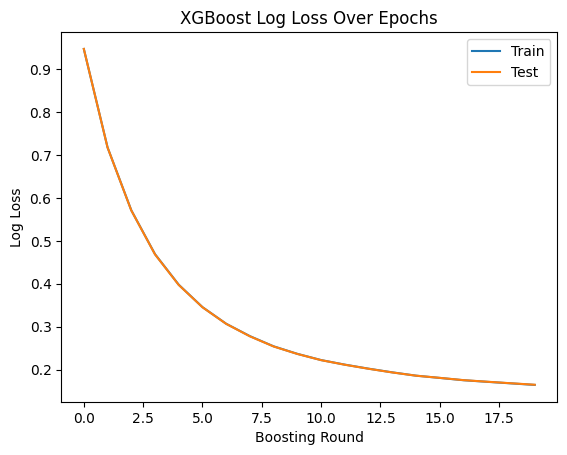

In [39]:
results = xgb_model.evals_result()

# Plot it
epochs = len(results['validation_0']['mlogloss'])
x_axis = range(epochs)

plt.plot(x_axis, results['validation_0']['mlogloss'], label='Train')
plt.plot(x_axis, results['validation_1']['mlogloss'], label='Test')
plt.xlabel('Boosting Round')
plt.ylabel('Log Loss')
plt.title('XGBoost Log Loss Over Epochs')
plt.legend()
plt.show()


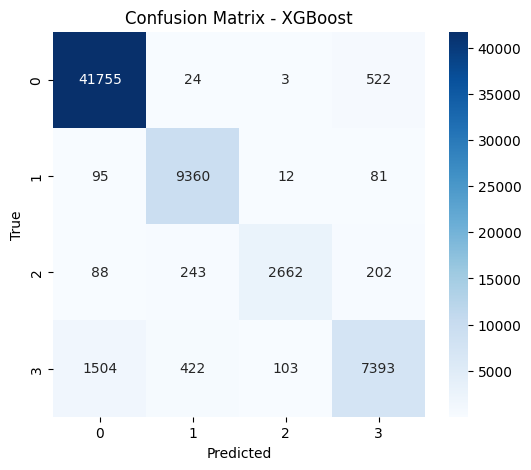

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

CM = confusion_matrix(y_test, y_predXGB, labels=[0, 1, 2, 3])

# Plotting the heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(CM, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1, 2, 3], yticklabels=[0, 1, 2, 3])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - XGBoost')
plt.show()
